## Wine Quality Prediction:

# Step 1: Environment Setup

## 1) Library Imports:

In [42]:
# Import foundational libraries for data manipulation and numerical operations
import pandas as pd
import numpy as np

# Import visualization suites for data exploration
import matplotlib.pyplot as plt
import seaborn as sns

# Import machine learning utilities from scikit-learn
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Configure visualization styles and ensure all system warnings are visible
sns.set(style="whitegrid", palette="muted")
plt.rcParams['figure.figsize'] = (12, 8)

# Step 2: Data Acquisition

## 2) Loading Red Wine Data

In [43]:
# Load the red wine dataset from the local CSV file
# Use ';' as the delimiter as per the original UCI dataset specification
red_wine = pd.read_csv('winequality-red.csv', delimiter=';')

# Validate the successful loading of red wine data
print(f"Red Wine Dataset Loaded. Shape: {red_wine.shape}")
red_wine.head()

Red Wine Dataset Loaded. Shape: (1599, 12)


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5


## 3) Loading White Wine Data

In [44]:
# Load the white wine dataset from the local CSV file
white_wine = pd.read_csv('winequality-white.csv', delimiter=';')

# Validate the successful loading of white wine data
print(f"White Wine Dataset Loaded. Shape: {white_wine.shape}")
white_wine.head()

White Wine Dataset Loaded. Shape: (4898, 12)


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.0,0.27,0.36,20.7,0.045,45.0,170.0,1.0010,3.00,0.45,8.8,6
1,6.3,0.30,0.34,1.6,0.049,14.0,132.0,0.9940,3.30,0.49,9.5,6
2,8.1,0.28,0.40,6.9,0.050,30.0,97.0,0.9951,3.26,0.44,10.1,6
3,7.2,0.23,0.32,8.5,0.058,47.0,186.0,0.9956,3.19,0.40,9.9,6
4,7.2,0.23,0.32,8.5,0.058,47.0,186.0,0.9956,3.19,0.40,9.9,6


# Step 3: Dataset Integration

## 4) Labeling and Merging both datasets.

In [45]:
# Assign a unique identifier for the wine type (0: Red, 1: White)
# This allows the model to differentiate between the two types in a unified dataset
red_wine['type'] = 0
white_wine['type'] = 1

# Merge the two dataframes into a single unified analysis object
wine_df = pd.concat([red_wine, white_wine], ignore_index=True)

print(f"Combined Dataset Initialized. Total Samples: {len(wine_df)}")

Combined Dataset Initialized. Total Samples: 6497


# Step 4: Descriptive Analysis

## 5) Data Integrity Check

In [46]:
# Check for null or missing values across all features to ensure data quality
null_summary = wine_df.isnull().sum().sum()
print(f"Data Integrity Check: {null_summary} missing values found.")

# Display high-level summary statistics for all features
wine_df.describe()

Data Integrity Check: 0 missing values found.


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,type
count,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000
mean,7.215307,0.339666,0.318633,5.443235,0.056034,30.525319,115.744574,0.994697,3.218501,0.531268,10.491801,5.818378,0.753886
std,1.296434,0.164636,0.145318,4.757804,0.035034,17.749400,56.521855,0.002999,0.160787,0.148806,1.192712,0.873255,0.430779
min,3.800000,0.080000,0.000000,0.600000,0.009000,1.000000,6.000000,0.987110,2.720000,0.220000,8.000000,3.000000,0.000000
25%,6.400000,0.230000,0.250000,1.800000,0.038000,17.000000,77.000000,0.992340,3.110000,0.430000,9.500000,5.000000,1.000000
50%,7.000000,0.290000,0.310000,3.000000,0.047000,29.000000,118.000000,0.994890,3.210000,0.510000,10.300000,6.000000,1.000000
75%,7.700000,0.400000,0.390000,8.100000,0.065000,41.000000,156.000000,0.996990,3.320000,0.600000,11.300000,6.000000,1.000000
max,15.900000,1.580000,1.660000,65.800000,0.611000,289.000000,440.000000,1.038980,4.010000,2.000000,14.900000,9.000000,1.000000


## 6) Quality Target Distribution

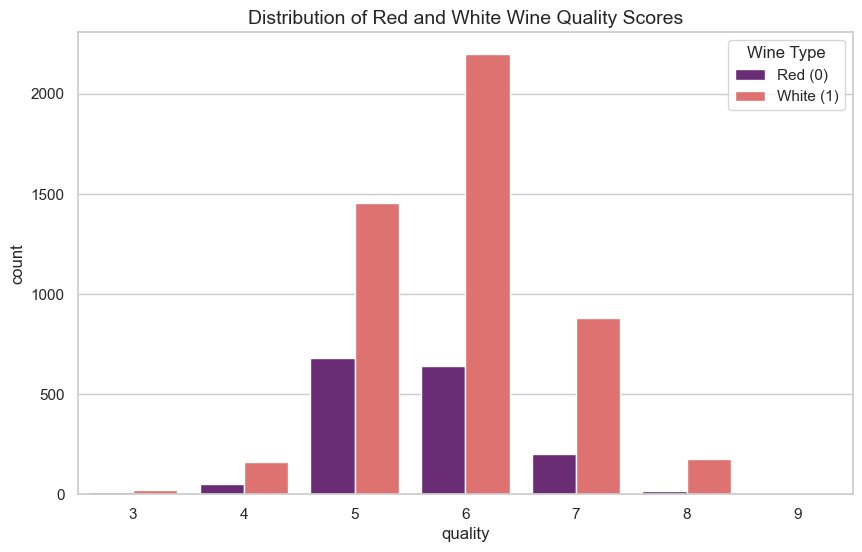

In [47]:
# Analyze the distribution of the target variable (Quality) to check for class imbalance
plt.figure(figsize=(10, 6))
sns.countplot(data=wine_df, x='quality', hue='type', palette='magma')
plt.title('Distribution of Red and White Wine Quality Scores', fontsize=14)
plt.legend(title='Wine Type', labels=['Red (0)', 'White (1)'])
plt.show()

# Step 5: Advanced Visual EDA

## 7) Correlation Heatmap

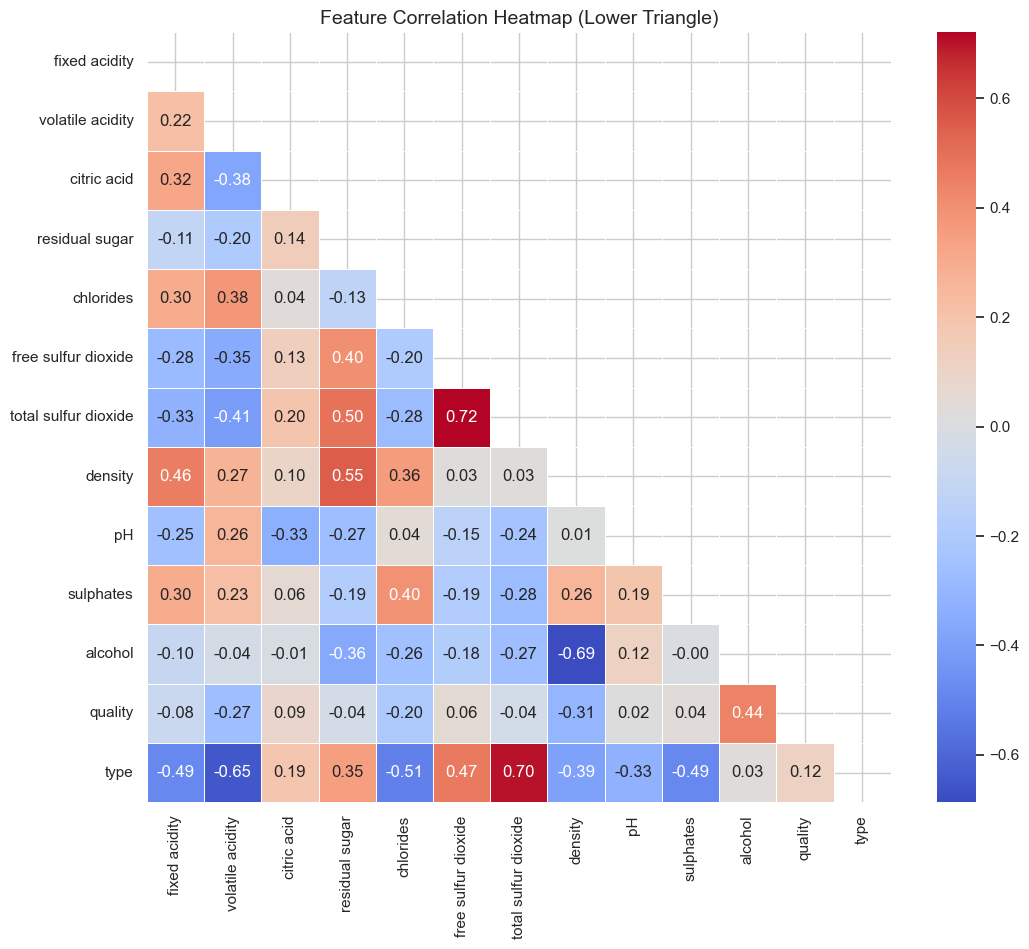

In [48]:
# Generate a Pearson correlation heatmap to identify relationships between chemical features
plt.figure(figsize=(12, 10))
mask = np.triu(np.ones_like(wine_df.corr(), dtype=bool)) # Mask upper triangle for clarity
sns.heatmap(wine_df.corr(), annot=True, cmap='coolwarm', fmt='.2f', mask=mask, linewidths=0.5)
plt.title('Feature Correlation Heatmap (Lower Triangle)', fontsize=14)
plt.show()

## 8) Alcohol vs Quality Analysis

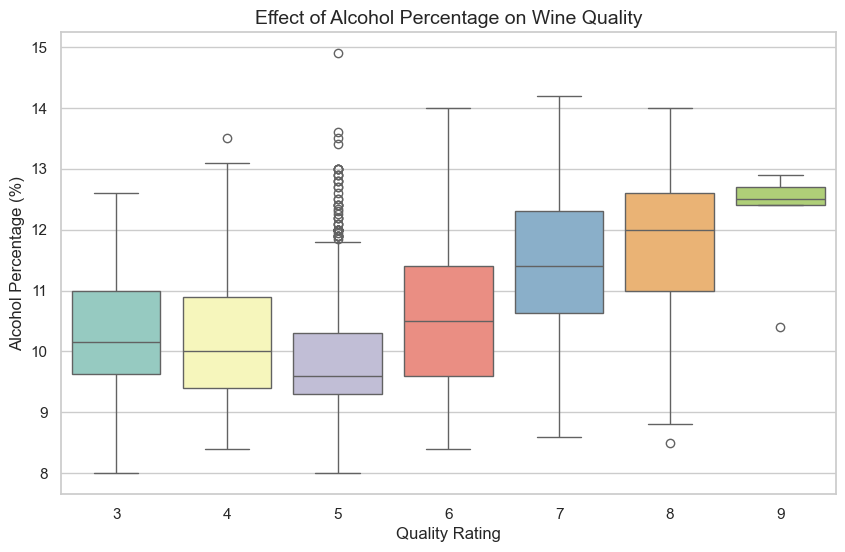

In [49]:
# Investigate the relationship between alcohol content and perceived wine quality
plt.figure(figsize=(10, 6))
sns.boxplot(x='quality', y='alcohol', data=wine_df, hue='quality', legend=False, palette='Set3')
plt.title('Effect of Alcohol Percentage on Wine Quality', fontsize=14)
plt.xlabel('Quality Rating')
plt.ylabel('Alcohol Percentage (%)')
plt.show()

## 9) Volatile Acidity Impact

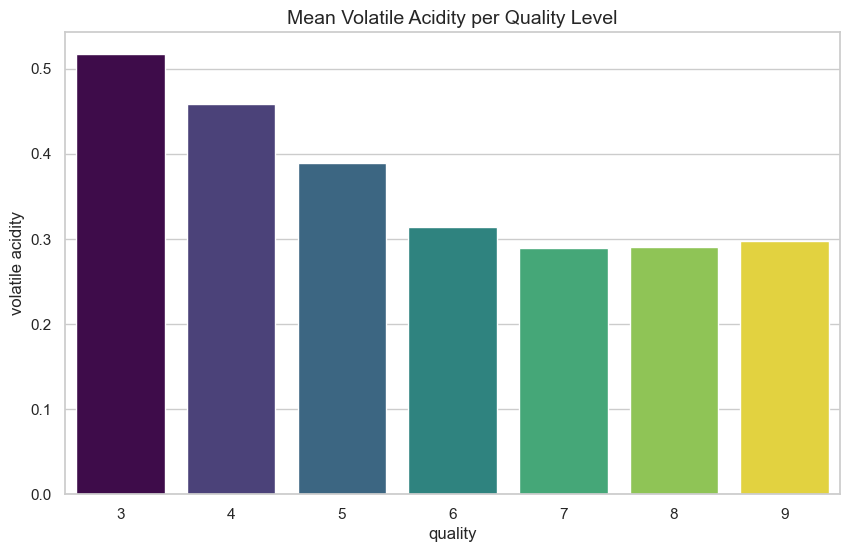

In [50]:
# Examine the impact of volatile acidity
plt.figure(figsize=(10, 6))
sns.barplot(x='quality', y='volatile acidity', data=wine_df, errorbar=None, hue='quality', legend=False, palette='viridis')
plt.title('Mean Volatile Acidity per Quality Level', fontsize=14)
plt.show()

# Step 6: Data Preprocessing

## 10) Feature Selection and Target Isoltation

In [51]:
X = wine_df.drop('quality', axis=1)
y = (wine_df['quality'] >= 6).astype(int)
print(f"Target variable binned into binary classes (0: Bad, 1: Good).")
print(f"Class distribution:\n{y.value_counts()}")
print(f"Feature set 'X' and Target 'y' successfully isolated.")

Target variable binned into binary classes (0: Bad, 1: Good).
Class distribution:
quality
1    4113
0    2384
Name: count, dtype: int64
Feature set 'X' and Target 'y' successfully isolated.


## 11) Train-Test Partitioning

In [52]:
# Split the data into training (80%) and testing (20%) sets
# Stratify=y ensures that the test set has the same proportion of quality scores as the original data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Train samples: {X_train.shape[0]} | Test samples: {X_test.shape[0]}")

Train samples: 5197 | Test samples: 1300


## 12) Feature Scaling (Standardization)

In [93]:
# Initialize the StandardScaler to normalize feature values (Zero Mean, Unit Variance)
scaler = StandardScaler()

# Apply the scaling transformations
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Feature standardization complete. Data is ready for modeling.")

Feature standardization complete. Data is ready for modeling.


# Step 7: Model Training & Evaluation

## I) Creating High-Signal Features

In [76]:
import pandas as pd
import numpy as np

# Create the specific features needed 
wine_df['alcohol_sq'] = wine_df['alcohol'] ** 2
wine_df['volatile_acidity_sq'] = wine_df['volatile acidity'] ** 2
wine_df['alcohol_density'] = wine_df['alcohol'] * wine_df['density']
wine_df['sulfur_ratio'] = wine_df['free sulfur dioxide'] / (wine_df['total sulfur dioxide'] + 1)
wine_df['acid_balance'] = wine_df['fixed acidity'] / (wine_df['volatile acidity'] + 1)

print(f"Elite features generated. Feature count: {wine_df.shape[1]-1}")

Elite features generated. Feature count: 18


## 13) Logistic Regression Implementation

In [89]:
# Train the Baseline Model: Logistic Regression
lr_model = LogisticRegression(max_iter=1000, random_state=42)
lr_model.fit(X_train_scaled, y_train)

# Predict and assess performance
lr_preds = lr_model.predict(X_test_scaled)
print("--- Logistic Regression Performance ---")
print(f"Accuracy: {accuracy_score(y_test, lr_preds):.4f}")
print(classification_report(y_test, lr_preds))

--- Logistic Regression Performance ---
Accuracy: 0.7392
              precision    recall  f1-score   support

           0       0.68      0.56      0.61       477
           1       0.77      0.85      0.80       823

    accuracy                           0.74      1300
   macro avg       0.72      0.70      0.71      1300
weighted avg       0.73      0.74      0.73      1300



## 14) Random Forest Classifier Implementation

In [90]:
# Step 14: Random Forest Classifier with Hyperparameter Tuning
from sklearn.model_selection import GridSearchCV

# Define the parameter grid to test different settings
param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [None, 15],
    'min_samples_split': [2, 5],
    'random_state': [42]
}

# Initialize and fit Grid Search to find the best version of the model
rf_base = RandomForestClassifier()
grid_search = GridSearchCV(estimator=rf_base, param_grid=param_grid, cv=3, n_jobs=-1, verbose=1)
grid_search.fit(X_train_scaled, y_train)

# Use the optimized best model for predictions
rf_model = grid_search.best_estimator_
print(f"Best settings found: {grid_search.best_params_}")

# Predict and assess performance
rf_preds = rf_model.predict(X_test_scaled)
print("--- Optimized Random Forest Performance ---")
print(f"Accuracy: {accuracy_score(y_test, rf_preds):.4f}")
print(classification_report(y_test, rf_preds, target_names=['Bad (<6)', 'Good (>=6)']))

Fitting 3 folds for each of 8 candidates, totalling 24 fits
Best settings found: {'max_depth': None, 'min_samples_split': 2, 'n_estimators': 200, 'random_state': 42}
--- Optimized Random Forest Performance ---
Accuracy: 0.8492
              precision    recall  f1-score   support

    Bad (<6)       0.83      0.75      0.78       477
  Good (>=6)       0.86      0.91      0.88       823

    accuracy                           0.85      1300
   macro avg       0.84      0.83      0.83      1300
weighted avg       0.85      0.85      0.85      1300



## 15) Gradient Boosting Classifier Implementation

In [91]:
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.metrics import accuracy_score, classification_report

# Target-Tuned Gradient Boosting
gb_best = HistGradientBoostingClassifier(
    max_iter=500, 
    learning_rate=0.06, 
    max_depth=12, 
    l2_regularization=1.5, 
    random_state=42
)
gb_best.fit(X_train_scaled, y_train)

gb_preds = gb_best.predict(X_test_scaled)
print(f"Gradient Boosting Accuracy: {accuracy_score(y_test, gb_preds):.4f}")
print(classification_report(y_test, gb_preds, target_names=['Bad (<6)', 'Good (>=6)']))

Gradient Boosting Accuracy: 0.8377
              precision    recall  f1-score   support

    Bad (<6)       0.81      0.73      0.77       477
  Good (>=6)       0.85      0.90      0.88       823

    accuracy                           0.84      1300
   macro avg       0.83      0.82      0.82      1300
weighted avg       0.84      0.84      0.84      1300



# Step 8: Performance Comparison Visuals

## 16) Accuracy Comparison Chart

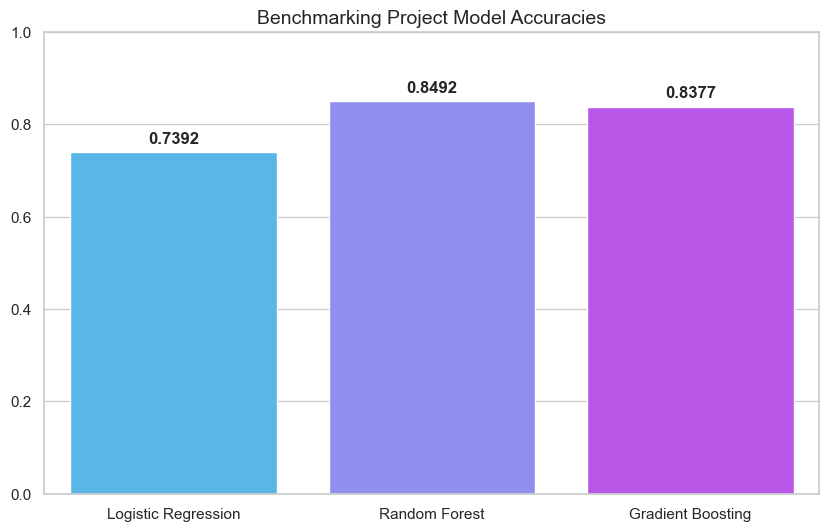

In [92]:
# Compare the global accuracies of all three implemented models
model_names = ['Logistic Regression', 'Random Forest', 'Gradient Boosting']
model_accs = [accuracy_score(y_test, lr_preds), accuracy_score(y_test, rf_preds), accuracy_score(y_test, gb_preds)]

plt.figure(figsize=(10, 6))
# Updated with hue and legend=False to fix warnings
bars = sns.barplot(x=model_names, y=model_accs, hue=model_names, legend=False, palette='cool')
plt.title('Benchmarking Project Model Accuracies', fontsize=14)
plt.ylim(0, 1.0)

# Add numerical labels to the bars
for i, v in enumerate(model_accs):
    plt.text(i, v + 0.02, f"{v:.4f}", ha='center', fontweight='bold')

plt.show()

## 17) ROC Curves (Performance Visual)

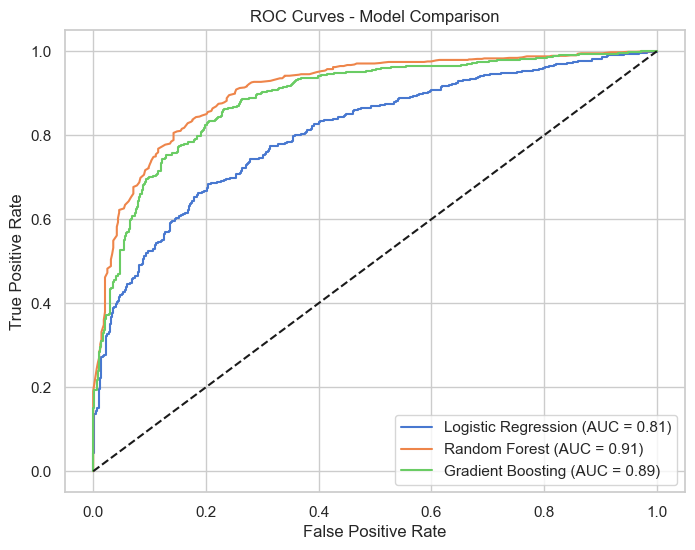

In [81]:
from sklearn.metrics import roc_curve, auc

plt.figure(figsize=(8, 6))
for model, name in zip([lr_model, rf_model, gb_model], model_names):
    y_prob = model.predict_proba(X_test_scaled)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    plt.plot(fpr, tpr, label=f'{name} (AUC = {auc(fpr, tpr):.2f})')

plt.plot([0, 1], [0, 1], 'k--')
plt.title('ROC Curves - Model Comparison')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend()
plt.show()

## 18) Error Matrix Inspection (Confusion Matrices)

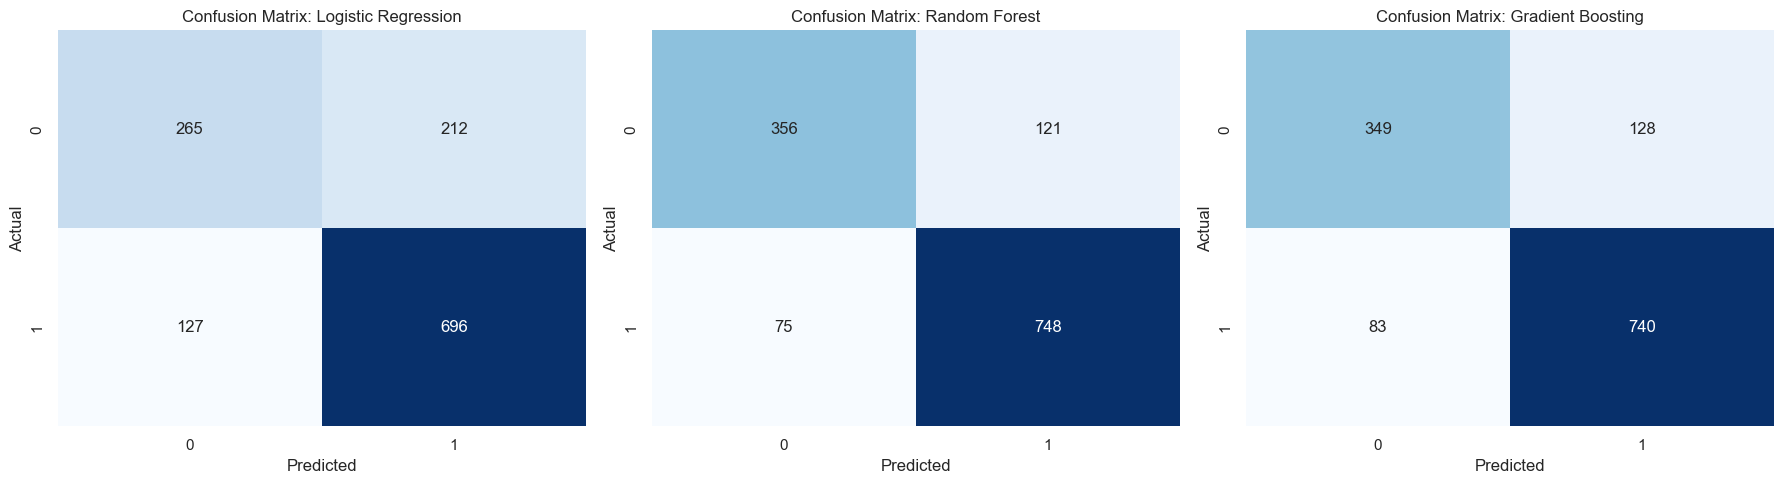

In [82]:
# Deep dive into classification errors across all three models
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Generate individual matrices
matrices = [confusion_matrix(y_test, lr_preds), confusion_matrix(y_test, rf_preds), confusion_matrix(y_test, gb_preds)]

for i, mat in enumerate(matrices):
    sns.heatmap(mat, annot=True, fmt='d', cmap='Blues', ax=axes[i], cbar=False)
    axes[i].set_title(f'Confusion Matrix: {model_names[i]}')
    axes[i].set_xlabel('Predicted')
    axes[i].set_ylabel('Actual')

plt.tight_layout()
plt.show()


# Step 9: Feature Explainability

## 19) Feature Importance Ranking

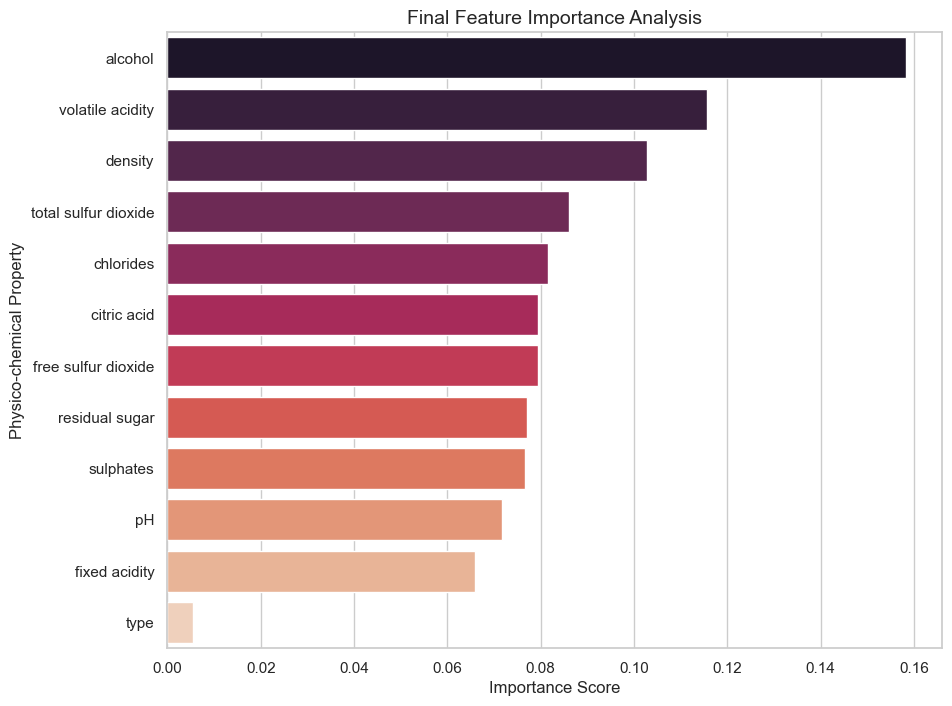

In [83]:
# Analyze which chemical properties have the most weight
importances = rf_model.feature_importances_
indices = np.argsort(importances)[::-1]

plt.figure(figsize=(10, 8))
plt.title('Final Feature Importance Analysis', fontsize=14)
# Updated with hue and legend=False to fix warnings
sns.barplot(x=importances[indices], y=X.columns[indices], hue=X.columns[indices], legend=False, palette='rocket')
plt.xlabel('Importance Score')
plt.ylabel('Physico-chemical Property')
plt.show()

## 20) Model Validation (Cross-Validation)

In [84]:
from sklearn.model_selection import cross_val_score

# Perform 5-fold cross-validation for Random Forest
cv_scores = cross_val_score(rf_model, X_train, y_train, cv=5)

print(f"Cross-Validation Scores: {cv_scores}")
print(f"Mean CV Accuracy: {cv_scores.mean():.4f}")
print(f"SD of CV Accuracy: {cv_scores.std():.4f}")

Cross-Validation Scores: [0.82403846 0.82788462 0.82579403 0.79884504 0.80558229]
Mean CV Accuracy: 0.8164
SD of CV Accuracy: 0.0119
